## This notebook only serves as visualization of different augmentations we will perform

#### The actual creation of the augmented dataset is done in create_augmented_data.ipynb

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
import skimage
from pathlib import Path

In [12]:
# iterate over C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\L1000765\crops_L1000765 but also over L1000766, L1000767, L1000768 and save the augmented images in a new folder called augmented_crops_L1000765, augmented_crops_L1000766, augmented_crops_L1000767, augmented_crops_L1000768 respectively
ref = Path.cwd().resolve()
crops = "L1000765/crops_L1000765"
augmented_crops = "L1000765/augmented_crops_L1000765"


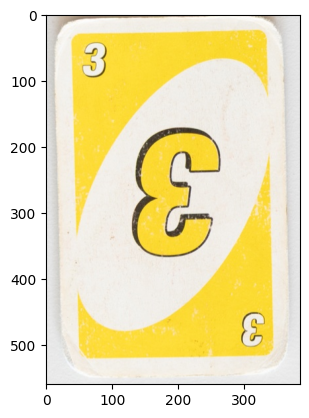

In [13]:
# open crop_0 in crops_L1000765 and display it
img = Image.open(os.path.join(ref, crops, "crop_0.jpg"))
plt.imshow(img)

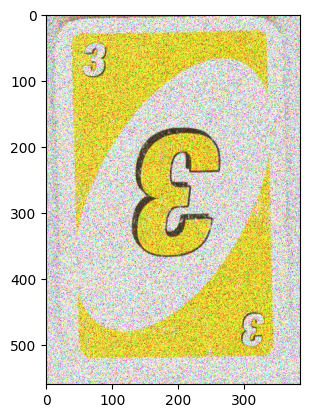

In [14]:
# add speckle noise to the image and display it
img_array = np.array(img)
noisy_img = skimage.util.random_noise(img_array, mode='speckle', var=0.1)
plt.imshow(noisy_img)

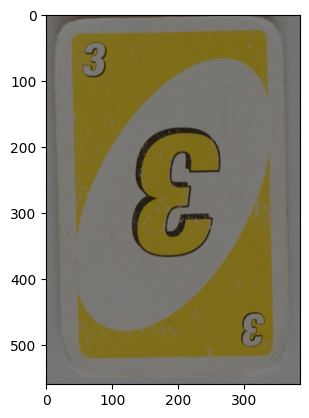

In [15]:
# dim the image and display it
dimmed_img = cv2.convertScaleAbs(img_array, alpha=0.5, beta=0)
plt.imshow(dimmed_img)

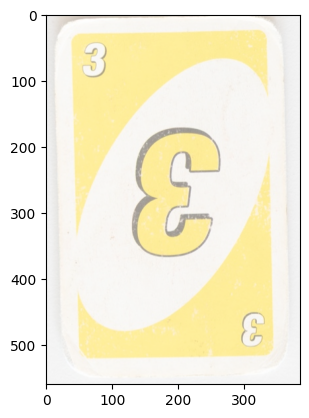

In [16]:
# lower contrast the image and display it
lower_contrast_img = cv2.convertScaleAbs(img_array, alpha=0.5, beta=128)
plt.imshow(lower_contrast_img)

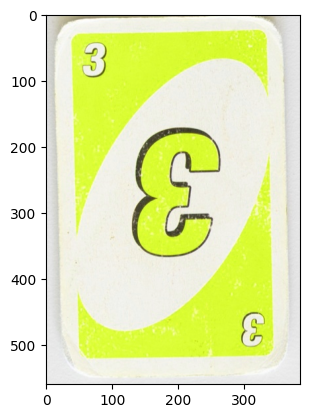

In [17]:
# change hue 
hue_img1 = cv2.cvtColor(img_array, cv2.COLOR_RGB2HSV)
hue_img1[:, :, 0] = (hue_img1[:, :, 0] + 10) % 180
hue_img1 = cv2.cvtColor(hue_img1, cv2.COLOR_HSV2RGB)
plt.imshow(hue_img1)

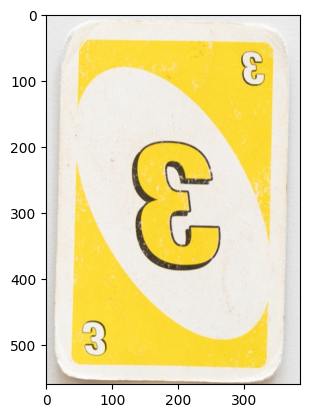

In [18]:
# flip vertically and display it
flipped_img = cv2.flip(img_array, 0)
plt.imshow(flipped_img)

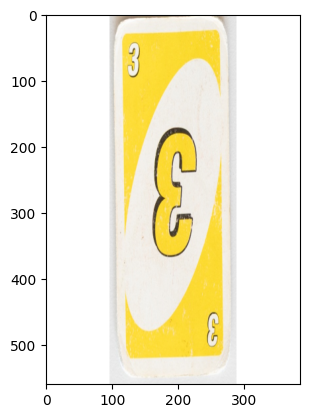

In [19]:
# squeeze (change proportion) the image and display it (can also stretch)
squeezed_img = cv2.resize(img_array, (img_array.shape[1] // 2, img_array.shape[0]))
# now we create a white image of the original size and paste the squeezed image in the center
squeezed_img_full = np.ones_like(img_array) * 255
# calculate the position to paste the squeezed image
x_offset = (squeezed_img_full.shape[1] - squeezed_img.shape[1]) // 2
y_offset = (squeezed_img_full.shape[0] - squeezed_img.shape[0]) // 2
squeezed_img_full[y_offset:y_offset + squeezed_img.shape[0], x_offset:x_offset + squeezed_img.shape[1]] = squeezed_img
plt.imshow(squeezed_img_full)

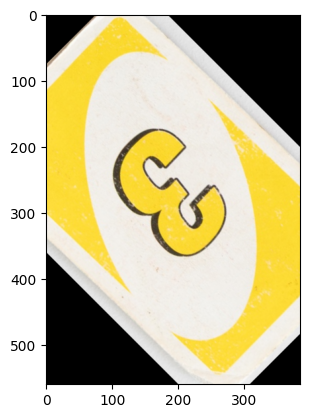

In [20]:
# rotate the image by 45 degrees and display it
(h, w) = img_array.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(img_array, M, (w, h))
plt.imshow(rotated_img)

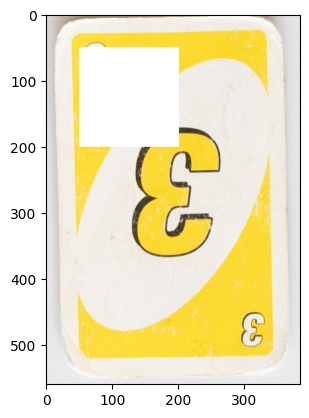

In [21]:
# cover the image with a white rectangle and display it
covered_img = img_array.copy()
cv2.rectangle(covered_img, (50, 50), (200, 200), (255, 255, 255), -1)
plt.imshow(covered_img)

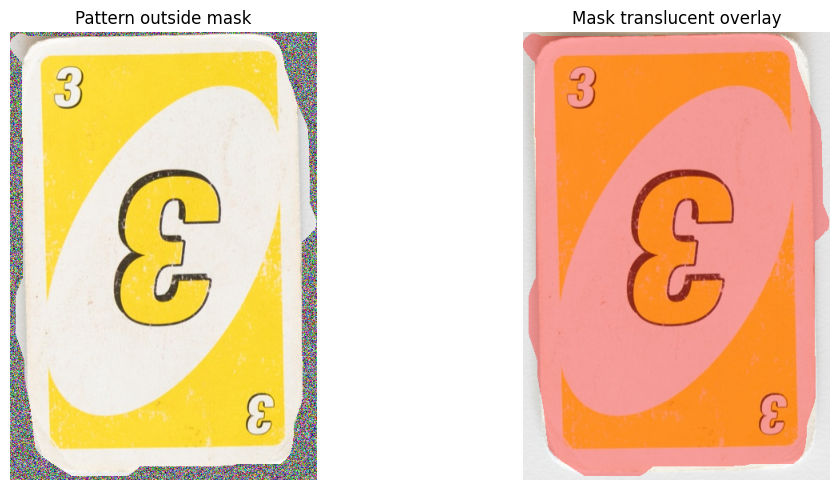

In [22]:
# replace pixels that aren't in mask (C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\L1000765\components_L1000766) with random colored patterns and display it
mask_path = os.path.join(ref, "L1000765/closed_components_L1000765/closed_component_0.jpg")
closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Use the same crop logic as reference_cards.ipynb
x, y, w, h = cv2.boundingRect(closed_mask)
mask_crop = closed_mask[y:y+h, x:x+w]

# Keep compatibility if jpeg rounding introduces a 1-2 px mismatch
if mask_crop.shape[:2] != img_array.shape[:2]:
    mask_crop = cv2.resize(mask_crop, (img_array.shape[1], img_array.shape[0]), interpolation=cv2.INTER_NEAREST)

mask_fg = mask_crop > 127
pattern_img = np.random.randint(0, 255, img_array.shape, dtype=np.uint8)
pattern_img[mask_fg] = img_array[mask_fg]

# translucent mask overlay on top of the original crop
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(pattern_img)
ax[0].set_title("Pattern outside mask")
ax[0].axis("off")

ax[1].imshow(img_array)
overlay = np.zeros((*mask_fg.shape, 4), dtype=np.float32)
overlay[..., 0] = 1.0  # red channel
overlay[..., 3] = mask_fg.astype(np.float32) * 0.35  # alpha where mask is foreground
ax[1].imshow(overlay)
ax[1].set_title("Mask translucent overlay")
ax[1].axis("off")

plt.tight_layout()

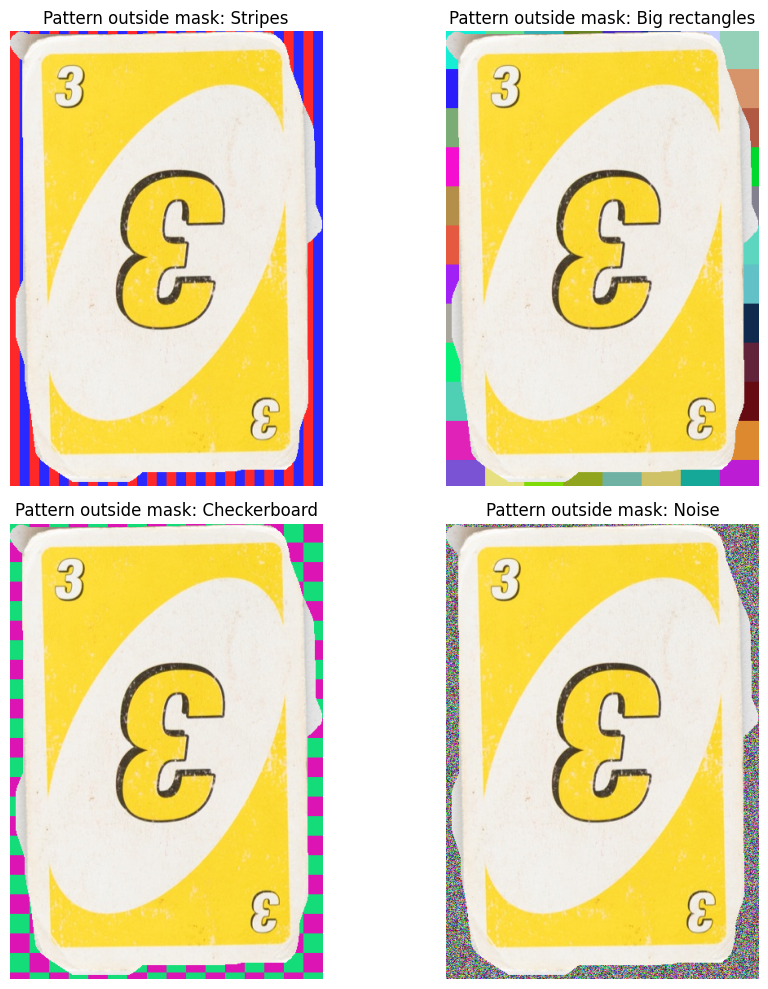

In [23]:
# same thing as above but different patterns: striped, bigger colored rectangles, checkerboard, etc.
# Recompute the aligned mask so this cell can run independently
mask_path = os.path.join(ref, "L1000765/closed_components_L1000765/closed_component_0.jpg")
closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
x, y, w, h = cv2.boundingRect(closed_mask)
mask_crop = closed_mask[y:y+h, x:x+w]
if mask_crop.shape[:2] != img_array.shape[:2]:
    mask_crop = cv2.resize(mask_crop, (img_array.shape[1], img_array.shape[0]), interpolation=cv2.INTER_NEAREST)
mask_fg = mask_crop > 127

H, W = img_array.shape[:2]

# 1) Vertical stripes
stripe_w = 12
stripe_pattern = np.zeros_like(img_array)
for c in range(0, W, stripe_w * 2):
    stripe_pattern[:, c:c+stripe_w] = (255, 40, 40)
    stripe_pattern[:, c+stripe_w:c+2*stripe_w] = (40, 40, 255)

# 2) Big colored rectangles (blocky mosaic)
block = 48
rect_pattern = np.zeros_like(img_array)
for r in range(0, H, block):
    for c in range(0, W, block):
        color = np.random.randint(0, 256, size=3, dtype=np.uint8)
        rect_pattern[r:r+block, c:c+block] = color

# 3) Checkerboard
tile = 24
checker_pattern = np.zeros_like(img_array)
for r in range(0, H, tile):
    for c in range(0, W, tile):
        if ((r // tile) + (c // tile)) % 2 == 0:
            checker_pattern[r:r+tile, c:c+tile] = (20, 220, 120)
        else:
            checker_pattern[r:r+tile, c:c+tile] = (220, 20, 180)

# 4) Random noise
noise_pattern = np.random.randint(0, 255, img_array.shape, dtype=np.uint8)

patterns = [
    ("Stripes", stripe_pattern),
    ("Big rectangles", rect_pattern),
    ("Checkerboard", checker_pattern),
    ("Noise", noise_pattern),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for i, (name, pattern) in enumerate(patterns):
    out = pattern.copy()
    out[mask_fg] = img_array[mask_fg]
    axes[i].imshow(out)
    axes[i].set_title(f"Pattern outside mask: {name}")
    axes[i].axis("off")

plt.tight_layout()